# 05: Sampling — Eryn from a toy MCMC to the global fit

**This notebook targets the development stack (LATW `dev` branch).** There is
no Colab path here; it needs the development versions of the LISA Analysis
Tools packages installed by `LISAanalysistools/install.sh`:

```bash
git clone https://github.com/lisa-analysis-tools/lisa-analysis-tools.git LISAanalysistools
bash LISAanalysistools/install.sh
```

Only `eryn`, `numpy`, `matplotlib`, `scipy`, and `lisatools` are used below —
everything runs on a laptop CPU in a few minutes.

In [1]:
import os

# Threading is pinned to 1 everywhere in this workshop (MPI-only policy;
# OMP-threaded kernels have caused out-of-memory kills on laptops).
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from copy import deepcopy
from lisatools.utils.constants import *

In this tutorial we climb the sampling ladder that the LISA global fit sits
on top of. [Eryn](https://mikekatz04.github.io/Eryn) is the MCMC engine for
the whole stack, and the global fit is — quite literally — the same engine
run on real LISA data with specialised proposals. We start with a
fixed-dimension ensemble on a 2-D Gaussian, add parallel tempering and
evidence, meet the `lisatools.sampling` glue layer, do a reversible-jump run
that infers *how many* signals are present, and close by naming exactly what
does and does not change on the way up to the global fit.

This is the *small → large* story for the sampler, the companion to the
*small → large* story notebook 00 told for the data objects.

### How to read this notebook

- **Casual reader:** read each `##` section heading and its **TL;DR** cell,
  run the one minimal cell under it, and skip the rest.
- **Pipeline developer:** also read the **"Going deeper"** subsections — they
  cover the array shapes, the temperature ladder, the sampler-layer classes,
  and how each piece maps onto the global fit.

## A fixed-dimension ensemble sampler

**TL;DR.** `eryn.ensemble.EnsembleSampler` advances a *population of
walkers* over a fixed-dimension parameter space. You hand it `nwalkers`,
`ndim`, a log-likelihood, and a prior (`ProbDistContainer` of per-parameter
distributions); you seed it with a `State` and call `run_mcmc`; you read the
samples back with `get_chain()`. Every other sampler in this notebook — and
the global fit — is this object with more machinery bolted on.

/var/folders/c0/p4f73hs11yz45_z7gqw3f5gw0000gn/T/ipykernel_48255/702222838.py:13: DeprecationWarning: eryn.prior.uniform_dist is deprecated. Use eryn.priors.analytical.UniformDistribution directly.
  prior = ProbDistContainer({0: uniform_dist(-8.0, 8.0),
/var/folders/c0/p4f73hs11yz45_z7gqw3f5gw0000gn/T/ipykernel_48255/702222838.py:14: DeprecationWarning: eryn.prior.uniform_dist is deprecated. Use eryn.priors.analytical.UniformDistribution directly.
  1: uniform_dist(-12.0, 12.0)})


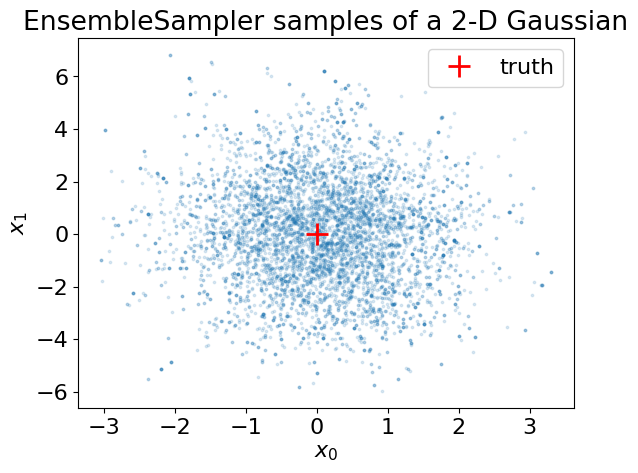

In [2]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import ProbDistContainer, uniform_dist

# A 2-D Gaussian log-likelihood (diagonal; standard deviations [1, 2]).
mean = np.array([0.0, 0.0])
inv_var = 1.0 / np.array([1.0, 2.0]) ** 2
def log_like(x):
    d = x - mean
    return -0.5 * np.sum(d ** 2 * inv_var)

# A prior: one 1-D distribution per parameter, keyed by parameter index.
prior = ProbDistContainer({0: uniform_dist(-8.0, 8.0),
                           1: uniform_dist(-12.0, 12.0)})

nwalkers, ndim = 16, 2
sampler = EnsembleSampler(nwalkers, ndim, log_like, prior)

# The State holds the full coordinate block (ntemps, nwalkers, nleaves, ndim);
# here ntemps = nleaves = 1. prior.rvs appends the ndim axis for us.
start = State(prior.rvs(size=(1, nwalkers, 1)))
sampler.run_mcmc(start, 400, burn=150, progress=False)

# get_chain -> {branch_name: (nsteps, ntemps, nwalkers, nleaves, ndim)}.
chain = sampler.get_chain()["model_0"][:, 0, :, 0, :]   # (nsteps, nwalkers, ndim)
plt.scatter(chain[..., 0].ravel(), chain[..., 1].ravel(), s=3, alpha=0.15)
plt.plot(0.0, 0.0, "r+", ms=16, mew=2, label="truth")
plt.xlabel("$x_0$"); plt.ylabel("$x_1$"); plt.legend()
plt.title("EnsembleSampler samples of a 2-D Gaussian");

### Going deeper: walkers, moves, the `State`, and the backend

- **Walkers and the default move.** An ensemble sampler evolves many walkers
  together; the default proposal is the affine-invariant *stretch* move, which
  proposes each walker's next point along the line to another walker. That is
  what lets a bare ensemble adapt to correlated Gaussians with no tuning. When
  you supply your own `moves=` (as in the RJ section) you replace this default.
- **Burn-in.** `run_mcmc(..., burn=150)` advances 150 steps that are *not*
  stored, then records the requested number of steps. The chains you get back
  therefore begin already past the initial transient. (There is no automatic
  convergence test here — deciding burn-in and thinning is on you.)
- **The `State`.** A `State` carries `coords` as a dict of branches. The full
  coordinate shape is `(ntemps, nwalkers, nleaves_max, ndim)`; the two size-1
  axes above are temperatures (next section) and *leaves* (the RJ section).
  A default single-branch run names its branch `"model_0"`.
- **The backend.** Chains, log-likelihoods, and temperatures live in
  `sampler.backend` (in-memory by default, or an
  [`HDFBackend`](https://mikekatz04.github.io/Eryn/html/user/backend.html)
  on disk). `get_chain()`, `get_log_like()`, `get_betas()`, and
  `get_nleaves()` are the readers you will use again and again.

Docs: [`EnsembleSampler`](https://mikekatz04.github.io/Eryn/html/user/ensemble.html),
[`State`](https://mikekatz04.github.io/Eryn/html/user/state.html),
[`ProbDistContainer`](https://mikekatz04.github.io/Eryn/html/user/prior.html).
(`eryn.prior.uniform_dist` still works but now emits a deprecation notice; the
modern spelling is `eryn.priors.analytical.UniformDistribution`.)

## Parallel tempering

**TL;DR.** Parallel tempering runs several copies of the ensemble at
decreasing inverse temperatures $\beta$ and samples the *flattened* target
$\beta\,\log\mathcal{L} + \log p$. Hot chains ($\beta \to 0$) roam freely
across low-probability valleys and pass good jumps down to the cold chain
($\beta = 1$) that you actually keep — which is how the sampler escapes
isolated posterior modes. Turn it on with `tempering_kwargs`.

/var/folders/c0/p4f73hs11yz45_z7gqw3f5gw0000gn/T/ipykernel_48255/3924996533.py:9: DeprecationWarning: eryn.prior.uniform_dist is deprecated. Use eryn.priors.analytical.UniformDistribution directly.
  prior1 = ProbDistContainer({0: uniform_dist(-30.0, 30.0)})


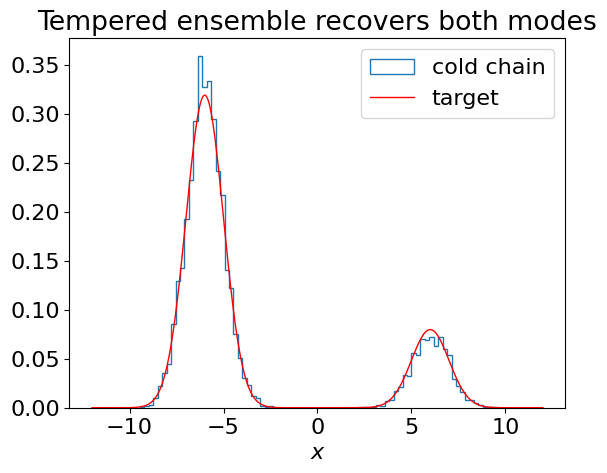

In [3]:
from scipy.special import logsumexp

# Two well-separated peaks (weights 0.8 / 0.2). A non-tempered ensemble tends
# to get stuck in whichever peak it started near; tempering samples both.
def log_like_bimodal(x):
    return logsumexp([np.log(0.8) - 0.5 * (x[0] + 6.0) ** 2,
                      np.log(0.2) - 0.5 * (x[0] - 6.0) ** 2])

prior1 = ProbDistContainer({0: uniform_dist(-30.0, 30.0)})
ntemps, nwalkers, burn = 8, 12, 300

sampler_pt = EnsembleSampler(
    nwalkers, 1, log_like_bimodal, prior1,
    tempering_kwargs=dict(ntemps=ntemps, Tmax=np.inf, stop_adaptation=burn),
)
sampler_pt.run_mcmc(State(prior1.rvs(size=(ntemps, nwalkers, 1))),
                    1200, burn=burn, progress=False)

# Cold chain = temperature index 0.
cold = sampler_pt.get_chain()["model_0"][:, 0, :, 0, 0].ravel()
xg = np.linspace(-12, 12, 400)
truth = np.exp([log_like_bimodal(np.array([xi])) for xi in xg])
plt.hist(cold, bins=80, density=True, histtype="step", label="cold chain")
plt.plot(xg, truth / np.trapezoid(truth, xg), "r", lw=1, label="target")
plt.xlabel("$x$"); plt.legend(); plt.title("Tempered ensemble recovers both modes");

### Going deeper: thermodynamic-integration evidence

A tempered run gives you the Bayesian *evidence* $Z = \int \mathcal{L}\,p\,d\theta$
almost for free, via thermodynamic integration:
$\log Z = \int_0^1 \langle \log\mathcal{L}\rangle_\beta\, d\beta$. Averaging
the log-likelihood within each temperature and integrating over the (frozen)
$\beta$ ladder estimates it. `stop_adaptation=burn` freezes the ladder after
burn-in so the recorded `betas` are constant — a precondition for the
integral.

In [4]:
from eryn.utils.utility import thermodynamic_integration_log_evidence

# Mean log-like within each temperature (average over steps and walkers).
logl_per_temp = sampler_pt.get_log_like().mean(axis=(0, 2))
betas = sampler_pt.get_betas()[-1]
assert np.all(betas == sampler_pt.get_betas()[0])   # ladder frozen after burn-in

logZ, dlogZ = thermodynamic_integration_log_evidence(betas, logl_per_temp)
print(f"log-evidence: {logZ:.3f} +/- {dlogZ:.3f}   (ntemps = {betas.size})")

log-evidence: -5.762 +/- 20.400   (ntemps = 8)


`dlogZ` is a *discretisation* error from having only a handful of
temperatures — it shrinks as you add rungs to the ladder, not as you add
steps. Comparing two models is then just a difference of `logZ` values (a
Bayes factor). In the LISA context you rarely integrate evidence by hand like
this; the reversible-jump section below is the more common way to let the data
choose a model, and the global fit does model selection *inside* the sampler.

### Going deeper: running many independent samplers at once (`nsamplers`)

`EnsembleSampler(nsamplers=N)` advances `N` **fully independent** tempered
ensembles in lockstep. They never interact, but at every step Eryn stacks all
`N` of them into a *single* batched likelihood/prior call — one big call that
keeps a GPU busy instead of `N` small ones. A leading `nsamplers` axis is
threaded through everything: coordinates become
`(nsamplers, ntemps, nwalkers, nleaves_max, ndim)`, and every stored array
(`get_chain`, `get_log_like`, `get_betas`, …) gains that axis right after the
step axis. Internally the axis is *folded* into the temperature axis, so every
move keeps working unchanged. It defaults to `1` (and is squeezed away at 1, so
everything above is unaffected). This is the mechanism a GB search uses to run
thousands of independent chains at once, and it replaces the older
`ParaEnsembleSampler`. See the "Running Many Independent Samplers at Once"
section of `Eryn/examples/Eryn_tutorial.ipynb`.

## The lisatools sampler layer

**TL;DR.** `lisatools.sampling` is the thin layer between a LISA likelihood
and Eryn: likelihood wrappers, priors shaped for GW parameters, custom moves,
and stopping criteria. The everyday entry point is
`AnalysisContainer.eryn_likelihood_function` (the container you built in 02 —
it *is* an Eryn log-like). The classes below are the specialised pieces the
global fit assembles on top of it; they are cheap to construct, so here we just
build a few to see the surface.

In [5]:
from lisatools.sampling.prior import SNRPrior
from lisatools.sampling.stopping import SNRStopping
from lisatools.sampling.moves.skymodehop import SkyMove

snr_prior = SNRPrior(rho_star=5.0)      # p(rho): rises then a heavy 1/rho^4 tail
print("SNR draws:", np.round(snr_prior.rvs(6), 2))

stop = SNRStopping(snr_limit=12.0)      # end a search once the best SNR clears 12
sky_hop = SkyMove(which="both")         # hop between the 8 equivalent LISA sky modes
print("stopping:", type(stop).__name__, " move:", type(sky_hop).__name__)

SNR draws: [16.19  3.04 54.33 11.31 57.49  5.35]
stopping: SNRStopping  move: SkyMove


### Going deeper: what each piece is

- **`sampling.likelihood.Likelihood` / `GlobalLikelihood`** — wrap a waveform
  generator into an Eryn log-like: they hold the injection (data + PSD) and
  compute the frequency-domain inner-product likelihood
  $\ln\mathcal{L} = -\tfrac12\,4\Delta f \sum_k |d_k - h_k|^2 / S_n(f_k)$,
  optionally delegating to a model's own `get_ll`. For the tutorials we prefer
  `AnalysisContainer.eryn_likelihood_function`, which is the `DomainBase`-aware
  path and needs no separate configuration.
- **`sampling.prior.SNRPrior`** — the analytic SNR prior
  $p(\rho) = 3\rho\,/\,[4\rho_*^2 (1 + \rho/4\rho_*)^5]$ with an inverse-CDF
  sampler. Paired with `AmplitudeFromSNR` it makes an amplitude prior that is
  flat *in SNR* rather than in amplitude — the sensible default for a search.
  `AmplitudeFrequencySNRPrior`, `GBPriorWrap`, and `FullGaussianMixtureModel`
  are its galactic-binary relatives.
- **`sampling.stopping.*`** (one line each):
  - `SNRStopping` — stop once the best in-chain SNR exceeds a limit.
  - `SearchConvergeStopping` / `SearchConvergeStopping2` — stop when the best
    log-likelihood stops improving for a set number of iterations.
  - `NLeavesSearchStopping` — stop when the maximum leaf (source) count
    plateaus.
  - `EvidenceStopping` — evaluates the tempered log-evidence each call (work in
    progress: it currently prints the estimate and always returns `False`).
  - `MPICommunicateStopping` — evaluate a stop decision on one MPI rank and
    broadcast it to the others.
- **`sampling.moves.skymodehop.SkyMove`** — an `MHMove` that proposes a jump
  between the discrete sky-position / inclination / polarization symmetries of
  the LISA response (eight equivalent modes). GW sky posteriors are strongly
  multimodal at exactly those reflections, and an ordinary random walk almost
  never crosses between them; this move proposes the *exact* symmetry swap so
  the chain can. `coord_frame` selects the sampling basis
  (`"lisa"` / `"ssb_ecliptic"` / `"icrs"`).

These are the building blocks; notebook 07 shows how the stock global-fit
recipes wire them into a full move stack. API reference:
[lisatools sampling docs](https://mikekatz04.github.io/LISAanalysistools).

## Reversible-jump MCMC: an unknown number of sources

**TL;DR.** When you do not know *how many* signals the data contain, the
dimension of the model is itself unknown. Reversible-jump MCMC (RJMCMC) lets
the sampler add and remove *leaves* (individual sources) inside named
*branches* (model types). You set `nleaves_min`/`nleaves_max` and
`rj_moves=True`; the sampler returns a posterior over the number of leaves as
well as over their parameters. This is the heart of the global fit, where the
tens of thousands of galactic binaries are leaves that RJ adds and removes.

/var/folders/c0/p4f73hs11yz45_z7gqw3f5gw0000gn/T/ipykernel_48255/2080463040.py:19: DeprecationWarning: eryn.prior.uniform_dist is deprecated. Use eryn.priors.analytical.UniformDistribution directly.
  priors_rj = {"pulse": ProbDistContainer({0: uniform_dist(0.2, 2.5),    # amplitude
/var/folders/c0/p4f73hs11yz45_z7gqw3f5gw0000gn/T/ipykernel_48255/2080463040.py:20: DeprecationWarning: eryn.prior.uniform_dist is deprecated. Use eryn.priors.analytical.UniformDistribution directly.
  1: uniform_dist(-10.0, 10.0)})}  # centre


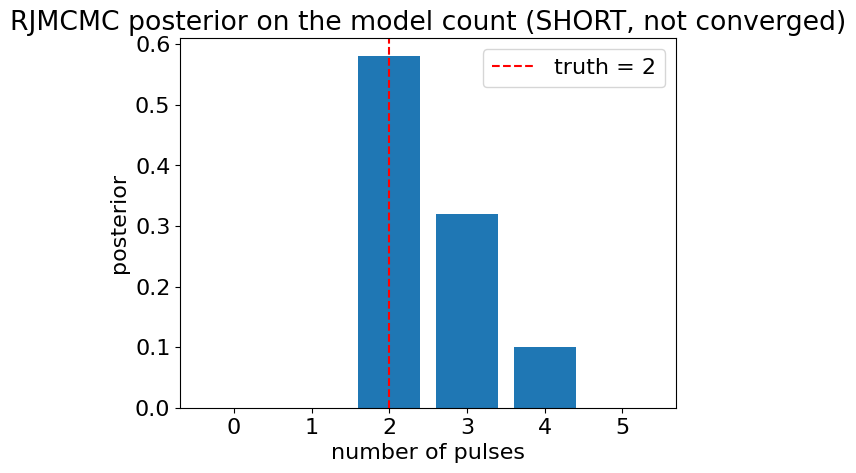

In [6]:
from eryn.moves import GaussianMove

# Data: an unknown number of 1-D Gaussian pulses (truth = 2) in white noise.
rng = np.random.default_rng(0)
grid = np.linspace(-10.0, 10.0, 200)
width, noise = 0.6, 0.1
def pulses(centers, amps):
    return (amps[:, None] *
            np.exp(-0.5 * ((grid[None, :] - centers[:, None]) / width) ** 2)).sum(0)
true_centers, true_amps = np.array([-3.0, 2.5]), np.array([1.0, 1.4])
data = pulses(true_centers, true_amps) + noise * rng.standard_normal(grid.size)

# Likelihood over a variable set of leaves: x is (n_active_leaves, ndim).
def log_like_rj(x, grid, data, width, noise):
    template = (x[:, 0][:, None] *
                np.exp(-0.5 * ((grid[None, :] - x[:, 1][:, None]) / width) ** 2)).sum(0)
    return -0.5 * np.sum(((template - data) / noise) ** 2)

priors_rj = {"pulse": ProbDistContainer({0: uniform_dist(0.2, 2.5),    # amplitude
                                         1: uniform_dist(-10.0, 10.0)})}  # centre
ntemps, nwalkers = 6, 12
nleaves_max, nleaves_min = {"pulse": 5}, {"pulse": 0}
in_model_move = GaussianMove({"pulse": np.diag([0.05, 0.1]) ** 2})   # updates params

sampler_rj = EnsembleSampler(
    nwalkers, {"pulse": 2}, log_like_rj, priors_rj,
    args=[grid, data, width, noise],
    tempering_kwargs=dict(ntemps=ntemps),
    branch_names=["pulse"], nleaves_max=nleaves_max, nleaves_min=nleaves_min,
    moves=in_model_move, rj_moves=True,      # rj_moves=True -> add/remove leaves
)

# coords: (ntemps, nwalkers, nleaves_max, ndim). inds turns individual leaves
# on/off; start every walker with exactly one active pulse.
coords = {"pulse": priors_rj["pulse"].rvs(size=(ntemps, nwalkers, nleaves_max["pulse"]))}
inds = {"pulse": np.zeros(coords["pulse"].shape[:-1], dtype=bool)}
inds["pulse"][:, :, 0] = True
sampler_rj.run_mcmc(State(coords, inds=inds), 500, burn=200, progress=False)

nleaves = sampler_rj.get_nleaves()["pulse"][:, 0].ravel()   # cold chain
plt.hist(nleaves, bins=np.arange(-0.5, nleaves_max["pulse"] + 1.5),
         density=True, rwidth=0.8)
plt.axvline(2, color="r", ls="--", label="truth = 2")
plt.xlabel("number of pulses"); plt.ylabel("posterior"); plt.legend()
plt.title("RJMCMC posterior on the model count (SHORT, not converged)");

> **This is a deliberately short, unconverged chain.** With 500 recorded
> steps the model-count posterior should peak near the true value (2) but its
> tails are noisy and depend on the seed. A real analysis needs far more steps,
> a considered burn-in, and better-tuned proposals than a fixed Gaussian —
> which is exactly what the global-fit move stack provides.

### Going deeper: branches, leaves, `inds`, and `coords`

- **Branch** = a model *type*, a named key in the dicts (`"pulse"` here). A
  real global fit has a branch per source class: `gb`, `mbh`, `emri`, ….
- **Leaf** = one *instance* of a branch (one source). `nleaves_max` /
  `nleaves_min` bound how many leaves a branch may hold; RJ moves the count
  within those bounds.
- **`coords`** is a dict `branch -> (ntemps, nwalkers, nleaves_max, ndim)`.
  **`inds`** is a dict `branch -> (ntemps, nwalkers, nleaves_max)` of booleans
  marking which leaves are currently *on*. Off leaves keep placeholder
  coordinates that RJ can later switch on.
- **The two move kinds.** `rj_moves=True` installs the default
  `DistributionGenerateRJ`, which proposes to add/remove a leaf by drawing its
  parameters from the prior. Your `moves=` argument (the `GaussianMove` here)
  is the *in-model* move: it updates existing leaves' parameters at fixed leaf
  count. With multiple branches the RJ move changes each branch's count by
  $\pm 1$.
- **Model selection as a special case.** Two branches each capped at one leaf,
  each walker holding exactly one of them, turns RJ into direct model
  comparison — the fraction of cold-chain time each branch is occupied is a
  proxy for the odds ratio (see the further/ exercises).

Docs: [Eryn moves](https://mikekatz04.github.io/Eryn/html/user/moves.html)
(`DistributionGenerateRJ`, `GaussianMove`),
[`State`](https://mikekatz04.github.io/Eryn/html/user/state.html).

## The global fit is this same sampler

Everything in this notebook is the global fit in miniature.

**The global fit IS this same sampler in terms of the organization of
information and the running infrastructure — states, branches, temperatures,
walkers, backends; what changes is the PROPOSALS, which in the global fit are
chosen by the user or the stock defaults (the moves you meet in notebook 07).**

Concretely, the mapping from this notebook to the global fit is one-to-one:

| here | in the global fit |
|---|---|
| `State` with `coords`/`inds` | the global state — every source's parameters and on/off flags |
| a *branch* (`"pulse"`) | a source class (`gb`, `mbh`, `emri`, `sobbh`, `psd`, …) |
| a *leaf* | one individual source (one galactic binary, one MBHB, …) |
| `ntemps` / `nwalkers` / backend | identical — same tempering, same ensemble, same (HDF) backend |
| the toy `log_like` | `AnalysisContainer` / `AnalysisContainerArray` over the real TDI residuals |
| `GaussianMove` + default RJ | the specialised move stack — F-statistic, GMM, sky-mode hop, ... |

So there is nothing new to learn about *how the sampler runs*: notebook 01 runs
one of these end to end in four lines, notebook 07 opens up the proposal stack
and the recipe/stage machinery that chooses the moves, and notebook 08 walks
every stock configuration. The rest is proposals.